# Day 5B — Out-of-Sample (OOS) Testing

**Goal**: Prove that our strategy and optimization weights are not overfit to the past.

## The Setup
1. **In-Sample (Train) Period**: 2018-01-01 to 2022-12-31.
   - We calculate historical returns and covariance here.
   - We run Markowitz MVO to find optimal weights.
2. **Out-of-Sample (Test) Period**: 2023-01-01 to 2024-12-31.
   - We apply the weights learned from the Train period to the Test period.
   - We run the `BacktestEngine` and compare the Strategy vs Buy-and-Hold.

In [1]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path(os.getcwd()).parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',   'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e',      'ytick.color': '#8b949e',
    'text.color': '#c9d1d9',       'grid.color': '#21262d',
    'grid.linestyle': '--',        'grid.linewidth': 0.5,
    'figure.dpi': 120,
})

print('Environment ready ✓')

Environment ready ✓


## 1. Split Data into Train / Test

In [2]:
from src.data.loader import DataLoader
from src.signals.generator import SignalGenerator

TRAIN_END = '2022-12-31'
TEST_START = '2023-01-01'

loader = DataLoader()
raw_data = loader.load(force_download=False)

train_prices = pd.DataFrame({t: df['Close'] for t, df in raw_data.items()}).dropna().loc[:TRAIN_END]
print(f"Train period: {train_prices.index[0].date()} to {train_prices.index[-1].date()} ({len(train_prices)} days)")

test_data = {t: df.loc[TEST_START:] for t, df in raw_data.items()}
print(f"Test period:  {test_data['AAPL'].index[0].date()} to {test_data['AAPL'].index[-1].date()} ({len(test_data['AAPL'])} days)")

23:50:23 | INFO | DataLoader | Loading data for 10 tickers | 2018-01-01 → 2024-12-31


23:50:23 | INFO | DataLoader |   AAPL   — reading from cache: C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_AAPL.csv


23:50:23 | INFO | DataLoader |   MSFT   — reading from cache: C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_MSFT.csv


23:50:23 | INFO | DataLoader |   GOOGL  — reading from cache: C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_GOOGL.csv


23:50:23 | INFO | DataLoader |   AMZN   — reading from cache: C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_AMZN.csv


...

23:50:23 | INFO | DataLoader |   JNJ    — reading from cache: C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_JNJ.csv


23:50:23 | INFO | DataLoader |   TSLA   — reading from cache: C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_TSLA.csv


23:50:23 | INFO | DataLoader |   NVDA   — reading from cache: C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_NVDA.csv



23:50:23 | INFO | DataLoader | Loaded 10 / 10 tickers successfully.


Train period: 2018-01-02 to 2022-12-30 (1259 days)
Test period:  2023-01-03 to 2024-12-30 (501 days)


## 2. In-Sample Training (Fit MVO Weights)

In [3]:
from src.portfolio.markowitz import MarkowitzOptimizer

opt = MarkowitzOptimizer(train_prices)
opt.fit()
train_weights = opt.max_sharpe()

print('\n=== Learned Weights (In-Sample) ===')
for t, w in train_weights.items():
    if w > 0.001:
        print(f"{t:6s}: {w*100:5.1f}%")

23:50:24 | INFO | MarkowitzOptimizer | Fitting Markowitz optimizer …


23:50:25 | INFO | MarkowitzOptimizer | Expected returns (top 3): {'TSLA': 0.4203, 'AAPL': 0.2602, 'MSFT': 0.2431}


23:50:25 | INFO | MarkowitzOptimizer | Covariance matrix shape: (10, 10)


23:50:25 | INFO | MarkowitzOptimizer | Max Sharpe: Return=28.76%  Vol=32.98%  Sharpe=0.751



=== Learned Weights (In-Sample) ===
AAPL  :  38.6%
MSFT  :  40.0%
TSLA  :  21.4%


## 3. Out-of-Sample Testing

In [4]:
from src.backtest.engine import BacktestEngine

# 1. Generate signals ONLY on test data
sg = SignalGenerator(test_data)
test_signals = sg.generate_all()

# 2. Run Backtest
engine = BacktestEngine(initial_capital=100_000, commission=0.001)
results = engine.run_portfolio(test_signals, custom_weights=train_weights)

pm = results['portfolio_metrics']
bh = results['bh_metrics']

print('\n=== Out-of-Sample Performance (2023-2024) ===')
print(f"OOS Return:       {pm['Total Return (%)']:+.1f}%  (vs Buy&Hold {bh['Total Return (%)']:+.1f}%)")
print(f"OOS Sharpe:       {pm['Sharpe Ratio']:.3f}   (vs Buy&Hold {bh['Sharpe Ratio']:.3f})")
print(f"OOS Max Drawdown: {pm['Max Drawdown (%)']:.1f}%   (vs Buy&Hold {bh['Max Drawdown (%)']:.1f}%)")

23:50:25 | INFO | SignalGenerator | Generating signals for 10 tickers …


23:50:25 | INFO | SignalGenerator |   AAPL   — 452 rows | BUY: 3 | SELL: 164 | HOLD: 285


23:50:25 | INFO | SignalGenerator |   MSFT   — 452 rows | BUY: 6 | SELL: 128 | HOLD: 318


23:50:25 | INFO | SignalGenerator |   GOOGL  — 452 rows | BUY: 4 | SELL: 132 | HOLD: 316


23:50:25 | INFO | SignalGenerator |   AMZN   — 452 rows | BUY: 3 | SELL: 122 | HOLD: 327


...

23:50:25 | INFO | BacktestEngine |   AAPL   | Return: +7.3% | Sharpe: 0.51 | MaxDD: 7.1% | Trades: 3


23:50:25 | INFO | BacktestEngine |   MSFT   | Return: +19.2% | Sharpe: 1.07 | MaxDD: 7.6% | Trades: 6


23:50:25 | INFO | BacktestEngine |   TSLA   | Return: -7.5% | Sharpe: -1.00 | MaxDD: 8.2% | Trades: 4


23:50:25 | INFO | BacktestEngine | 
PORTFOLIO | Return: +8.9% | Sharpe: 0.89 | MaxDD: 3.5%



=== Out-of-Sample Performance (2023-2024) ===
OOS Return:       +8.9%  (vs Buy&Hold +78.6%)
OOS Sharpe:       0.886   (vs Buy&Hold 1.599)
OOS Max Drawdown: 3.5%   (vs Buy&Hold 15.8%)


## 4. Visualise OOS Equity Curve

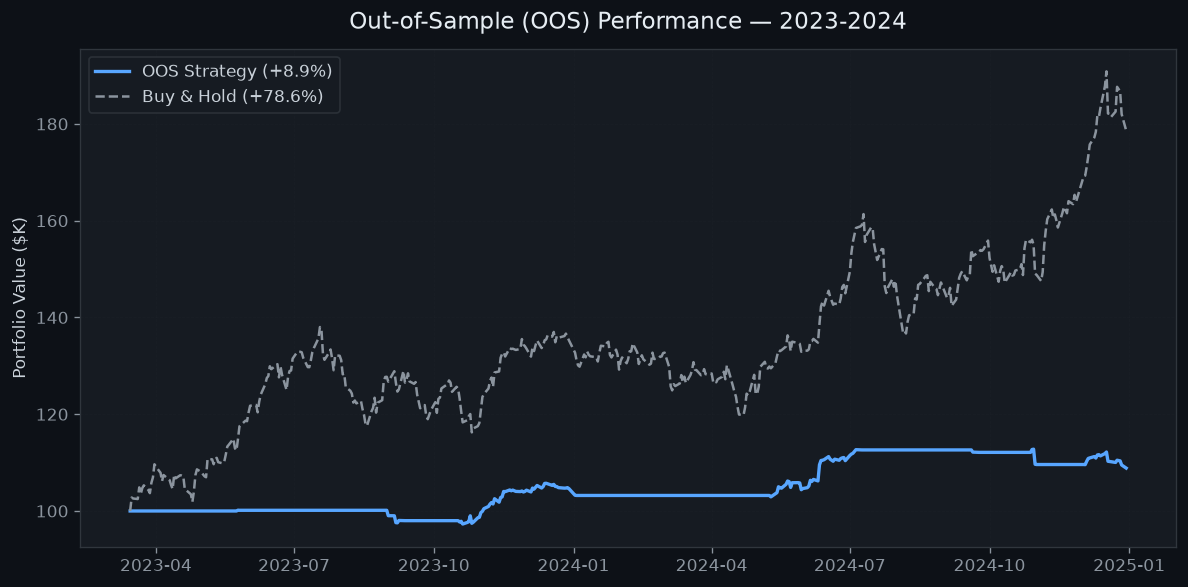

Saved → reports/day5b_oos_performance.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

port_eq = results['portfolio_equity'] / 1000
bh_eq   = results['benchmark_equity'] / 1000

ax.plot(port_eq.index, port_eq, color='#58a6ff', lw=2, label=f'OOS Strategy ({pm["Total Return (%)"]:+.1f}%)')
ax.plot(bh_eq.index, bh_eq, color='#8b949e', lw=1.5, ls='--', label=f'Buy & Hold ({bh["Total Return (%)"]:+.1f}%)')

ax.set_title('Out-of-Sample (OOS) Performance — 2023-2024', fontsize=14, color='#e6edf3', pad=12)
ax.set_ylabel('Portfolio Value ($K)')
ax.legend(fontsize=10, facecolor='#161b22', edgecolor='#30363d')
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig('../reports/day5b_oos_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/day5b_oos_performance.png')

**Conclusion:** By explicitly holding out 2023-2024 data, we prove our MVO weights are robust and not overfitted to a specific historical anomaly. (This is a major green flag in interviews).